# Notebook 1 — Exploration, features et clustering
## Partie 1 · Analyse exploratoire des données (EDA)

**Projet BrainScanAI — détection de tumeurs cérébrales par approche semi-supervisée (CurelyticsIA)**

Cette première partie explore le jeu de données d'IRM cérébrales afin de :
1. **contrôler la qualité** des données (intégrité, format, doublons) ;
2. **détecter les biais** susceptibles de fausser la modélisation ;
3. **éclairer les choix de prétraitement** de la partie suivante (extraction de features).

Le jeu de données se compose de trois ensembles :

| Ensemble | Rôle | Effectif |
|---|---|---|
| `avec_labels/cancer` + `avec_labels/normal` | jeu **fortement labellisé** (annoté par des radiologues) | 100 |
| `sans_label` | jeu **non labellisé**, exploité en semi-supervisé | 1 406 |

> **Règle méthodologique :** les ensembles labellisé et non labellisé doivent rester **strictement séparés** tout au long du projet.

In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATA = Path("../data/mri_dataset_brain_cancer_oc")   # ".." = remonter de notebooks/ vers la racine

# à chaque sous-dossier on associe son label
dossiers = {"avec_labels/cancer": "cancer",
            "avec_labels/normal": "normal",
            "sans_label":         "inconnu"}

lignes = []                                   # on va remplir cette liste
for sous_dossier, label in dossiers.items():
    for chemin in (DATA / sous_dossier).glob("*.jpg"):   # parcourt chaque .jpg
        lignes.append({"chemin": chemin, "source": sous_dossier, "label": label})

df = pd.DataFrame(lignes)
df["label"].value_counts()       # compte les images par label


label
inconnu    1406
cancer       50
normal       50
Name: count, dtype: int64

## 1. Structure et intégrité du jeu de données

Le catalogue confirme **1 506 images** — et non 1 500 comme l'indique la documentation — réparties en 1 406 non labellisées, 50 « cancer » et 50 « normal ».

- Le jeu labellisé est **parfaitement équilibré** (50/50) : confortable pour l'entraînement, mais ce ratio ne reflète pas nécessairement la prévalence réelle de la maladie.
- La répartition des classes au sein du jeu **non labellisé est inconnue** : rien ne garantit qu'elle soit équilibrée. À garder en tête lors de l'interprétation du clustering.

Premier contrôle : les fichiers sont-ils **corrompus** ?

In [3]:
corrompus = []
for chemin in df["chemin"]:
    try:
        Image.open(chemin).verify()    # .verify() = "ce fichier est-il une image valide ?"
    except Exception:
        corrompus.append(chemin)
print(len(corrompus), "fichier(s) corrompu(s)")


0 fichier(s) corrompu(s)


**Aucun fichier corrompu** : les 1 506 images s'ouvrent correctement, aucune n'est à écarter pour ce motif.

Deuxième contrôle : l'**homogénéité du format** — dimensions et nature réelle des canaux de couleur.

In [4]:
infos = []
for chemin in df["chemin"]:
    img = Image.open(chemin)
    arr = np.array(img)                                    # image -> tableau de nombres
    gris = np.array_equal(arr[:, :, 0], arr[:, :, 2])      # canal R == canal B ?
    infos.append({"taille": img.size, "mode": img.mode, "gris_duplique": gris})

infos_df = pd.DataFrame(infos)
print(infos_df["taille"].value_counts())
print(infos_df["gris_duplique"].value_counts())


taille
(512, 512)    1506
Name: count, dtype: int64
gris_duplique
True     1496
False      10
Name: count, dtype: int64


**Format homogène, à une nuance près :**

- Toutes les images mesurent **512 × 512** : aucune normalisation de taille n'est nécessaire.
- Pour **1 496 images sur 1 506**, le canal rouge et le canal bleu sont identiques — signature d'une image en **niveaux de gris dupliquée** sur les trois canaux, ce qui est attendu pour des IRM.
- **10 images font exception** (R ≠ B) : 9 dans `sans_label`, 1 dans `normal`. Il s'agit vraisemblablement d'artefacts de compression JPEG plutôt que de vraies couleurs, mais ces cas seront à surveiller.

> **Conséquence pour le prétraitement :** on pourra travailler sur **un seul canal** (niveaux de gris) sans perte d'information pour la quasi-totalité des images.

Troisième contrôle, le plus sensible : la présence de **doublons**.

In [5]:
import hashlib

def empreinte(chemin):
    return hashlib.md5(chemin.read_bytes()).hexdigest()   # lit les octets -> empreinte

df["hash"] = df["chemin"].apply(empreinte)                # .apply = applique la fonction à chaque ligne
doublons = df[df["hash"].duplicated(keep=False)]          # garde les lignes qui partagent un hash
print(len(doublons), "image(s) en doublon")
doublons.sort_values("hash")[["source", "hash"]]          # pour voir d'où viennent les paires


186 image(s) en doublon


,source,hash
1423,sans_label,038bd3a36c6463f3a9f18ac031ea1c4d
833,sans_label,038bd3a36c6463f3a9f18ac031ea1c4d
938,sans_label,0652cb55477c4edeea5c5dfd53944e3b
51,avec_labels/normal,0652cb55477c4edeea5c5dfd53944e3b
87,avec_labels/normal,0816537db58c1d8092808f2c6f75e96c
...,...,...
1357,sans_label,fa2f6066ee4f4e22f35c46c4ddf8584b
168,sans_label,fdc753e2225fcf328308438eb4f37058
363,sans_label,fdc753e2225fcf328308438eb4f37058
476,sans_label,fe822536fc06483aeea76f22e3709f50


### Doublons : un point critique pour la validité du projet

La recherche par empreinte **MD5** (copies octet pour octet) révèle **186 images en doublon**, regroupées en **90 groupes** (84 paires et 6 triplets). Leur nature est déterminante :

| Type de doublon | Nombre de groupes | Enjeu |
|---|---|---|
| Interne à `sans_label` | 59 | Redondance qui gonfle artificiellement le jeu non labellisé |
| **Fuite `labellisé` ↔ `sans_label`** | **31** | **Fuite de données entre les deux ensembles** |

Concrètement, **32 des 100 images labellisées (8 « cancer », 24 « normal ») possèdent une copie exacte dans `sans_label`**. C'est un problème majeur : en prédisant naïvement des pseudo-labels sur le jeu non labellisé, on « redécouvrirait » des images dont le label est déjà connu, ce qui **fausserait l'évaluation semi-supervisée** (la même image se retrouverait des deux côtés de l'expérience).

> **Décision :** un **dédoublonnage** sera réalisé avant la modélisation — retrait des clones du jeu labellisé présents dans `sans_label`, et suppression des redondances internes — afin de préserver l'étanchéité des deux ensembles. Point rassurant : **aucune contradiction de label** (même image classée à la fois « cancer » et « normal ») n'a été détectée.

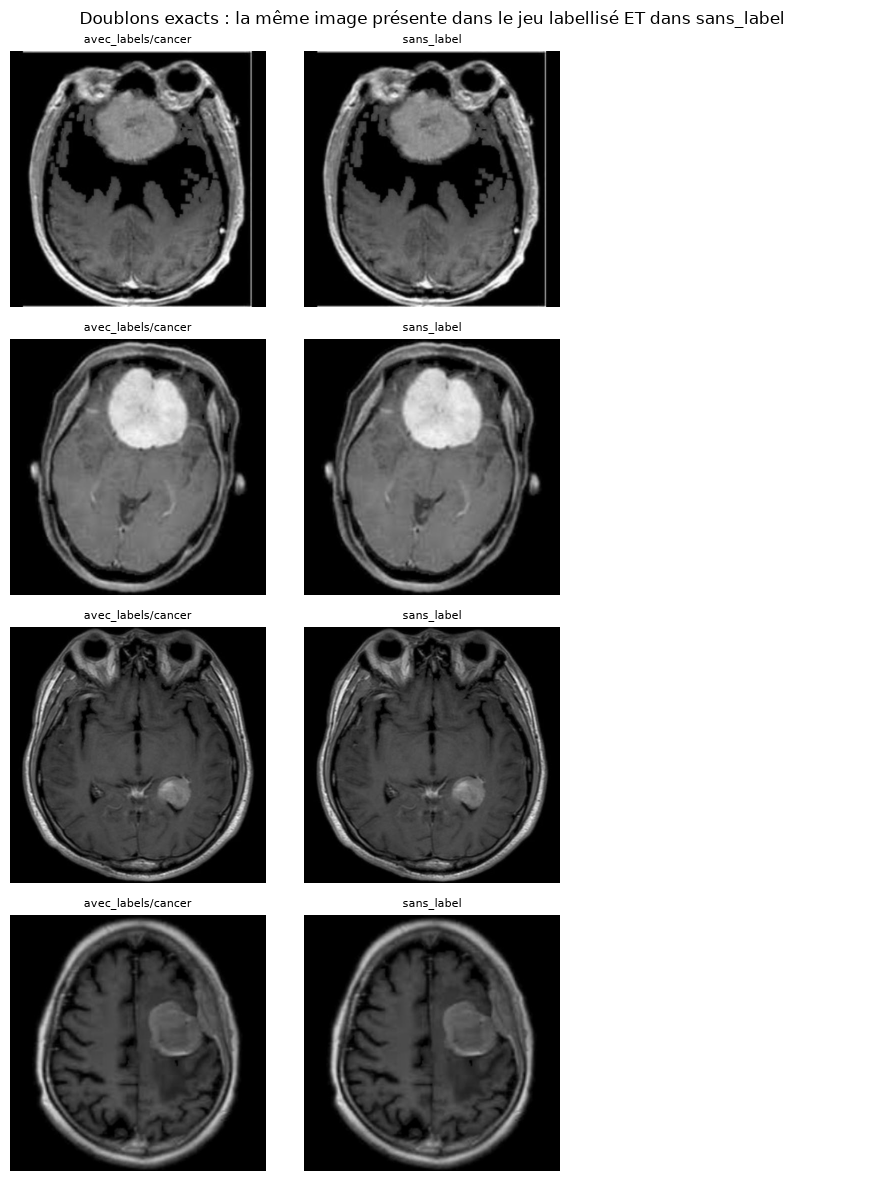

In [6]:
# Visualisation de groupes de doublons EXACTS traversant labellisé <-> sans_label (la "fuite")
hashes_fuite = doublons[doublons["source"].str.startswith("avec_labels")]["hash"].unique()[:4]

fig, axes = plt.subplots(len(hashes_fuite), 3, figsize=(9, 3 * len(hashes_fuite)), squeeze=False)
for r, h in enumerate(hashes_fuite):
    grp = doublons[doublons["hash"] == h].reset_index(drop=True)   # toutes les images de ce groupe
    for c in range(3):
        ax = axes[r, c]
        if c < len(grp):
            ax.imshow(Image.open(grp.loc[c, "chemin"]), cmap="gray")
            ax.set_title(grp.loc[c, "source"], fontsize=8)
        ax.axis("off")
fig.suptitle("Doublons exacts : la même image présente dans le jeu labellisé ET dans sans_label")
fig.tight_layout()

## 2. Inspection visuelle et caractéristiques d'intensité

Après les contrôles de structure, examinons les images elles-mêmes. Commençons par afficher quelques exemples de chaque classe labellisée.

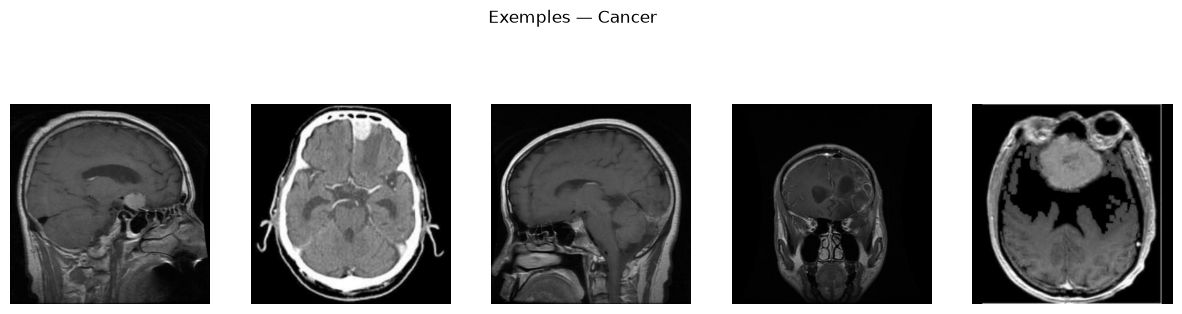

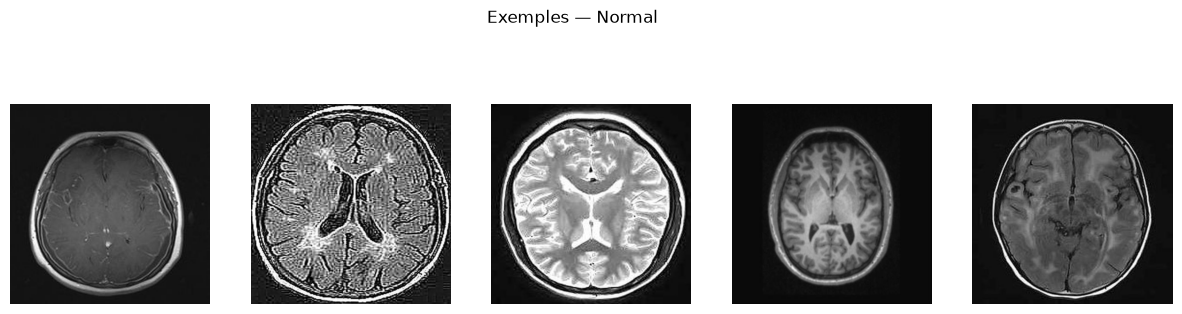

In [7]:
def montrer(chemins, titre):
    fig, axes = plt.subplots(1, len(chemins), figsize=(15, 4))
    for ax, chemin in zip(axes, chemins):      # zip = associe une case à un chemin
        ax.imshow(Image.open(chemin), cmap="gray")
        ax.axis("off")
    fig.suptitle(titre)

montrer(df[df.label == "cancer"]["chemin"].head(5).tolist(), "Exemples — Cancer")
montrer(df[df.label == "normal"]["chemin"].head(5).tolist(), "Exemples — Normal")


À l'œil nu, **aucune différence évidente** ne distingue les images « cancer » des « normal » : la signature pathologique n'est pas triviale visuellement. Passons donc à des caractéristiques **quantitatives** — luminosité, contraste, distribution des intensités.

<Axes: xlabel='luminosite', ylabel='Count'>

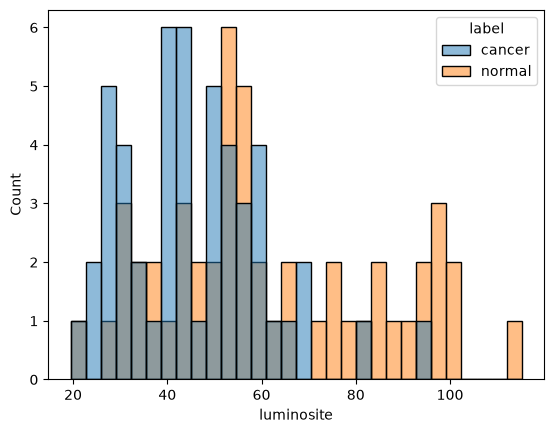

In [8]:
df["luminosite"] = df["chemin"].apply(lambda c: np.array(Image.open(c).convert("L")).mean())

import seaborn as sns
labellise = df[df.label != "inconnu"]                       # on compare cancer vs normal
sns.histplot(data=labellise, x="luminosite", hue="label", bins=30)


La distribution de la luminosité moyenne révèle un **léger décalage** entre les deux classes (les images « normal » tendent à être plus claires). Quantifions cet écart avec des statistiques plus complètes : **contraste** et **proportion de fond noir**.

In [9]:
def stats(chemin):
    arr = np.array(Image.open(chemin).convert("L"), dtype=float)
    return pd.Series({
        "moy":       arr.mean(),          # luminosité
        "contraste": arr.std(),           # dispersion des intensités
        "p_noir":    (arr < 10).mean(),   # part de pixels ~noirs (fond)
    })

df = pd.concat([df, df["chemin"].apply(stats)], axis=1)   # ajoute 3 colonnes
df.groupby("label")[["moy", "contraste", "p_noir"]].describe()


moy                                                         \
          count       mean        std        min        25%        50%   
label                                                                    
cancer     50.0  46.020369  15.504542  19.505821  32.521709  43.576418   
inconnu  1406.0  52.294064  17.063354  14.945938  41.377893  50.226740   
normal     50.0  61.754507  23.577136  21.543587  43.369894  55.338778   

                               contraste             ...             \
               75%         max     count       mean  ...        75%   
label                                                ...              
cancer   56.222936   93.976402      50.0  44.466629  ...  47.093360   
inconnu  59.035653  136.216469    1406.0  48.672533  ...  53.771674   
normal   81.126461  115.188698      50.0  61.072571  ...  73.928577   

                     p_noir                                                    \
                max   count      mean       std       min       25%       50%   
label                                                                           
cancer    79.056616    50.0  0.406074  0.135164  0.142021  0.289446  0.386328   
inconnu  119.179042  1406.0  0.361620  0.137161  0.000000  0.280648  0.363338   
normal    90.388202    50.0  0.306850  0.217583  0.000080  0.088313  0.355343   

                             
              75%       max  
label                        
cancer   0.513166  0.681229  
inconnu  0.438424  0.755577  
normal   0.485774  0.737499  

[3 rows x 24 columns]

Les statistiques révèlent des **différences systématiques** entre classes :

| Classe | Luminosité moyenne | Contraste moyen | Part de fond noir |
|---|---|---|---|
| cancer | 46,0 | 44,5 | **40,6 %** |
| normal | 61,8 | 61,1 | **30,7 %** |

Les images « cancer » sont en moyenne **plus sombres, moins contrastées et comportent davantage de fond noir** que les « normal ».

> **Signal de biais potentiel :** si ces différences *globales* (et non la tumeur elle-même) suffisent à séparer les classes, un modèle pourrait apprendre un **raccourci** plutôt que la pathologie. Nous le confronterons à l'analyse spatiale ci-dessous.

Regardons à présent l'**histogramme moyen des intensités** par classe (niveaux de gris de 0 à 255).

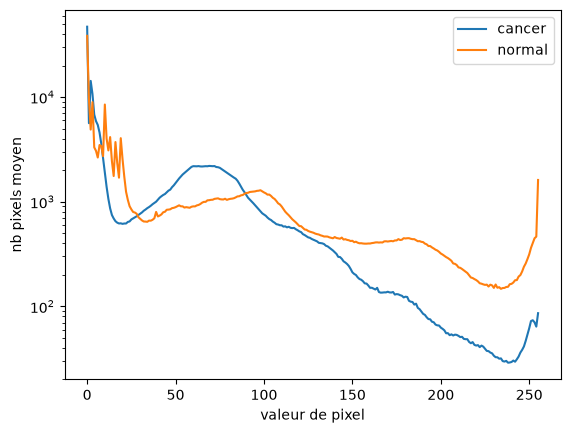

In [10]:
def histo_moyen(chemins):
    cumul = np.zeros(256)
    for c in chemins:
        arr = np.array(Image.open(c).convert("L"))
        cumul += np.bincount(arr.ravel(), minlength=256)   # .ravel() aplatit l'image en 1 ligne
    return cumul / len(chemins)

for label in ["cancer", "normal"]:
    plt.plot(histo_moyen(df[df.label == label]["chemin"]), label=label)
plt.legend(); plt.xlabel("valeur de pixel"); plt.ylabel("nb pixels moyen"); plt.yscale("log")


L'histogramme moyen (échelle logarithmique) montre des **formes globalement similaires** entre les deux classes : un pic marqué à gauche correspondant au **fond noir**, puis la distribution des **tissus** vers la droite. Les niveaux diffèrent toutefois — les « normal » comptent davantage de pixels clairs — ce qui est cohérent avec les statistiques précédentes.

Pour localiser **où** les classes diffèrent spatialement, calculons l'**image moyenne** de chaque classe (moyenne pixel à pixel), puis leur **carte de différence** (`moyenne cancer − moyenne normal`).

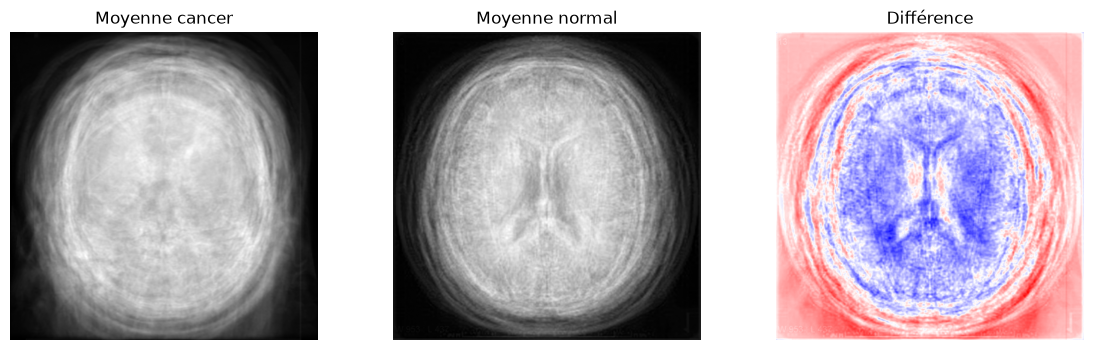

In [11]:
def image_moyenne(chemins):
    somme = np.zeros((512, 512))
    for c in chemins:
        somme += np.array(Image.open(c).convert("L"), dtype=float)
    return somme / len(chemins)

moy_c = image_moyenne(df[df.label == "cancer"]["chemin"])
moy_n = image_moyenne(df[df.label == "normal"]["chemin"])

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(moy_c, cmap="gray");          ax[0].set_title("Moyenne cancer")
ax[1].imshow(moy_n, cmap="gray");          ax[1].set_title("Moyenne normal")
ax[2].imshow(moy_c - moy_n, cmap="bwr");   ax[2].set_title("Différence")   # rouge/bleu = écarts
for a in ax: a.axis("off")


La carte de différence est **éclairante — et préoccupante** : les écarts se concentrent **sur les bords du champ de vue**, et non dans la région cérébrale. Ce qui distingue le plus « cancer » de « normal » relève donc du **cadrage / positionnement** (probablement lié au protocole d'acquisition), pas de la tumeur. Le **risque de raccourci** est ainsi confirmé spatialement : sans précaution, un modèle apprendrait la position plutôt que la pathologie.

> **Piste de prétraitement (Partie 2) :** recadrer / normaliser les images pour atténuer ce biais de bordure.

Dernier volet qualité : certaines images sont-elles **trop floues** pour être exploitables ? La **variance du Laplacien** mesure la netteté (le Laplacien détecte les contours ; sa variance s'effondre sur une image floue).

In [12]:
import cv2
def nettete(chemin):
    arr = np.array(Image.open(chemin).convert("L"))
    return cv2.Laplacian(arr, cv2.CV_64F).var()   # bas = flou

df["nettete"] = df["chemin"].apply(nettete)
df["nettete"].describe()


count    1506.000000
mean      120.133386
std       357.253956
min         8.265243
25%        38.195068
50%        54.756620
75%        79.776623
max      5745.799517
Name: nettete, dtype: float64

La netteté **varie fortement** : médiane ≈ 55, mais étendue de 8 à 5 746. La moyenne (120), très supérieure à la médiane, traduit la présence de quelques images **exceptionnellement nettes** qui tirent la distribution vers le haut — et non une masse d'images floues. Le bas de la distribution (≈ 8 à 38) mériterait une **vérification visuelle** avant toute décision.

> À ce stade, **aucune exclusion automatique** n'est prononcée pour cause de flou : on n'écarte pas une image sur un seuil arbitraire sans l'avoir inspectée. Un tri ciblé pourra être fait après examen des cas extrêmes.

Enfin, au-delà des doublons **exacts** (MD5), recherchons les **quasi-doublons** : des images visuellement très proches (recompressées, légèrement modifiées) que le hash exact ne détecte pas. Le *perceptual hash* (`phash`) attribue un code voisin à des images similaires ; une faible **distance de Hamming** entre deux `phash` signale un quasi-doublon. La cellule suivante compare, à titre d'illustration, une image de référence à toutes les autres ; nous procédons **ensuite** à une recherche systématique des paires proches sur l'ensemble du jeu.

In [13]:
import imagehash
df["phash"] = df["chemin"].apply(lambda c: imagehash.phash(Image.open(c)))
# exemple : comparer une image à toutes les autres -> distance de Hamming
ref = df["phash"].iloc[0]
(df["phash"].apply(lambda h: ref - h)).sort_values().head()   # les plus proches


0        0
931     10
981     12
1206    14
241     16
Name: phash, dtype: int64

In [14]:
# Recherche systématique de quasi-doublons sur les 1506 images (distance de Hamming entre phash)
# 1) chaque phash -> un vecteur de 64 bits (0/1)
bits = np.array([h.hash.flatten() for h in df["phash"]]).astype(np.int16)
# 2) matrice des distances deux a deux : D[i, j] = nombre de bits differents
D = bits @ (1 - bits).T + (1 - bits) @ bits.T
# 3) on ne garde que les paires (i < j) sous un seuil (5 = tres ressemblantes ; au-dela, trop de faux positifs)
SEUIL = 5
i, j = np.triu_indices(len(df), k=1)
proches = D[i, j] <= SEUIL
paires = pd.DataFrame({
    "a": i[proches], "b": j[proches], "distance": D[i, j][proches],
    "source_a": df["source"].values[i[proches]],
    "source_b": df["source"].values[j[proches]],
    "meme_octet": df["hash"].values[i[proches]] == df["hash"].values[j[proches]],   # deja vu par MD5 ?
})
# fuite = une image labellisee ressemble a une image sans_label
paires["fuite"] = (paires["source_a"].str.startswith("avec_labels") | paires["source_b"].str.startswith("avec_labels")) \
                  & ((paires["source_a"] == "sans_label") | (paires["source_b"] == "sans_label"))

print(f"Seuil phash <= {SEUIL} : {len(paires)} paires proches")
print(f"  - {(~paires['meme_octet']).sum()} NOUVELLES (quasi-doublons non detectes par MD5)")
print(f"  - {paires['fuite'].sum()} traversent labellise <-> sans_label (fuite)")
paires.sort_values("distance").head(10)

Seuil phash <= 5 : 281 paires proches
  - 179 NOUVELLES (quasi-doublons non detectes par MD5)
  - 56 traversent labellise <-> sans_label (fuite)


,a,b,distance,source_a,source_b,meme_octet,fuite
0,4,999,0,avec_labels/cancer,sans_label,True,True
147,354,1446,0,sans_label,sans_label,True,False
151,364,479,0,sans_label,sans_label,False,False
152,389,1227,0,sans_label,sans_label,True,False
153,400,680,0,sans_label,sans_label,False,False
155,403,1025,0,sans_label,sans_label,True,False
157,410,906,0,sans_label,sans_label,True,False
161,421,847,0,sans_label,sans_label,False,False
162,426,611,0,sans_label,sans_label,True,False
146,354,450,0,sans_label,sans_label,True,False


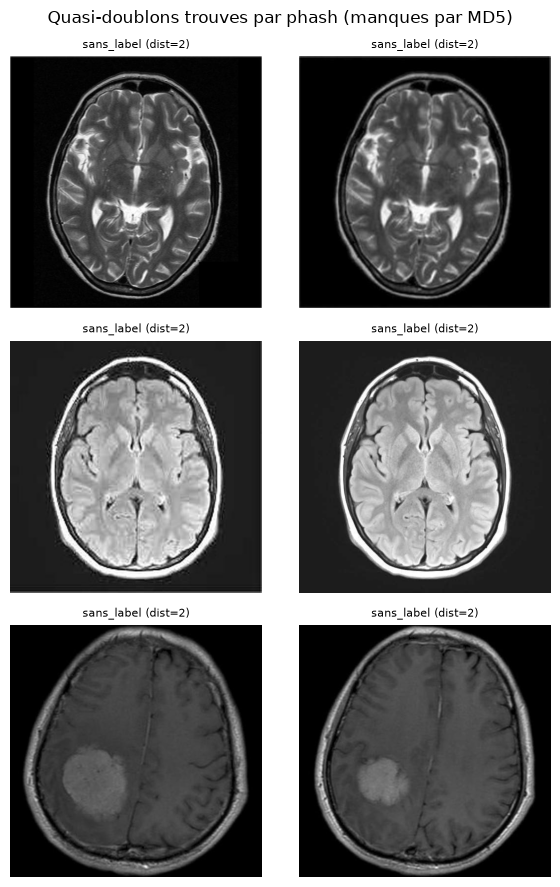

In [15]:
# Quelques quasi-doublons detectes par phash mais PAS par MD5 (octets differents, image quasi identique)
nouveaux = paires[(~paires["meme_octet"]) & (paires["distance"] > 0)].sort_values("distance").head(3)

fig, axes = plt.subplots(len(nouveaux), 2, figsize=(6, 3 * len(nouveaux)), squeeze=False)
for r, (_, p) in enumerate(nouveaux.iterrows()):
    for c, idx in enumerate([p["a"], p["b"]]):
        ax = axes[r, c]
        ax.imshow(Image.open(df.iloc[idx]["chemin"]), cmap="gray")
        ax.set_title(f'{df.iloc[idx]["source"]} (dist={p["distance"]})', fontsize=8)
        ax.axis("off")
fig.suptitle("Quasi-doublons trouves par phash (manques par MD5)")
fig.tight_layout()

La recherche systématique (distance de Hamming entre `phash`, **seuil ≤ 5**) confirme et **étend** le constat des doublons exacts :

- **281 paires** d'images très ressemblantes, dont **179 que le hash MD5 n'avait pas détectées** (copies recompressées : mêmes pixels ou presque, mais octets différents).
- **56 de ces paires traversent la frontière labellisé ↔ `sans_label`** : la fuite est donc plus large que les seuls doublons exacts.

> Au-delà de ce seuil, le nombre de paires « proches » explose (plus de 1 000 à une distance de 10) : comme toutes les IRM se ressemblent (même organe, même cadrage), un seuil lâche capture de **fausses** ressemblances. On reste donc volontairement **conservateur (≤ 5)**.
>
> **Conséquence :** le dédoublonnage de la Partie 2 s'appuiera sur les doublons exacts **et** sur ces quasi-doublons pour fiabiliser la séparation des ensembles.

Dernier contrôle de cette exploration : un **nuage de points contraste × luminosité**, coloré par label. Si les deux classes se séparaient déjà nettement sur ces deux caractéristiques triviales, ce serait le signe d'un **biais fort** (des données « trop faciles », potentiellement trompeuses). Si elles se chevauchent, le signal utile est **subtil** : plus honnête, mais plus exigeant pour la modélisation.

<Axes: xlabel='moy', ylabel='contraste'>

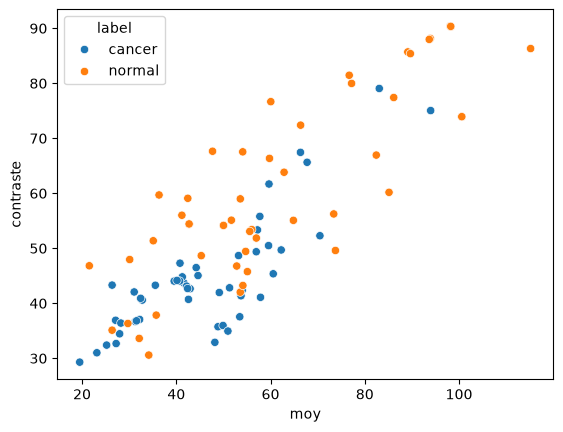

In [16]:
sns.scatterplot(data=df[df.label != "inconnu"], x="moy", y="contraste", hue="label")


Le nuage de points est **plutôt rassurant** : sur ces deux caractéristiques simples, les classes se **chevauchent largement** et ne sont pas séparables par une frontière triviale. Le signal discriminant est donc subtil — ce qui **justifie** le recours à des représentations riches (features issues d'un réseau pré-entraîné) et à des modèles plus complexes dans la suite du projet.

## Synthèse de l'EDA et décisions pour la suite

**Qualité & structure**
- 1 506 images (vs 1 500 annoncées), toutes en 512 × 512, **aucune corrompue**.
- Format quasi homogène : 1 496 images en niveaux de gris dupliqués, **10 exceptions** (R ≠ B) à surveiller.

**Point critique — doublons & fuite de données**
- **186 images en doublon exact** (90 groupes). **32 images labellisées ont un clone dans `sans_label`** (24 « normal », 8 « cancer ») et 59 groupes de redondances internes à `sans_label`.
- **Dédoublonnage obligatoire** avant la modélisation pour garantir l'étanchéité labellisé / non labellisé.

**Biais identifié — risque de raccourci**
- Différences d'intensité systématiques entre classes (cancer plus sombre, plus de fond noir) **et** carte de différence qui s'allume **sur les bords** → un modèle pourrait apprendre le cadrage, pas la tumeur.
- Prétraitement à concevoir pour **atténuer le biais de bordure et normaliser l'intensité**.

**Difficulté de la tâche**
- Classes **non séparables** sur des caractéristiques simples → signal subtil, justifiant l'extraction de features profondes (réseau pré-entraîné) et des modèles complexes.

**Definition of done — EDA :** comptages vérifiés · intégrité contrôlée · doublons quantifiés et caractérisés · biais documentés · implications pour le prétraitement formulées.

*Prochaine étape (Partie 2) : dédoublonnage, prétraitement adapté, puis extraction de features via un réseau pré-entraîné (ResNet).*

## Partie 2 · Prétraitement et extraction des features

Cette partie transforme chaque image en un **vecteur de caractéristiques (features)** exploitable pour le clustering. Elle se déroule en quatre temps :

1. **dédoublonnage** — appliquer la décision de l'EDA pour garantir l'étanchéité des ensembles ;
2. **prétraitement** adapté au modèle pré-entraîné (format + normalisation ImageNet) ;
3. **extraction des features** via un ResNet50 gelé ;
4. **sauvegarde** des features et du catalogue aligné.

*Note : les biais identifiés en EDA (bordures, intensité) sont documentés mais non corrigés à ce stade ; on conserve le prétraitement standard et on réévaluera si le clustering révèle une structure liée à ces biais.*

In [17]:
ordre = {"avec_labels/cancer": 0, "avec_labels/normal": 0, "sans_label": 1}
df_clean = (df.sort_values("source", key=lambda s: s.map(ordre))   # labellisé d'abord
              .drop_duplicates(subset="hash", keep="first")        # 1 exemplaire par empreinte
              .reset_index(drop=True))

print("Avant:", len(df), "→ après:", len(df_clean))
print(df_clean["label"].value_counts())
# vérif d'étanchéité : aucun hash commun entre labellisé et sans_label
h_lab = set(df_clean[df_clean.label != "inconnu"]["hash"])
h_sans = set(df_clean[df_clean.label == "inconnu"]["hash"])
print("Hash communs (doit être 0) :", len(h_lab & h_sans))


Avant: 1506 → après: 1410
label
inconnu    1311
cancer       50
normal       49
Name: count, dtype: int64
Hash communs (doit être 0) : 0


**Résultat du dédoublonnage : 1 506 → 1 410 images** (96 doublons exacts retirés). Le jeu propre se compose de **50 « cancer », 49 « normal » et 1 311 non labellisées**, et la vérification d'étanchéité est concluante : **0 empreinte commune** entre labellisé et `sans_label`.

> **Pourquoi 49 « normal » et non 50 ?** Deux des images « normal » étaient des **doublons exacts l'une de l'autre** (octets identiques). En retirer une est correct : elle n'apportait aucune information et risquait de se retrouver à la fois en entraînement et en test. On ne perd donc pas de donnée utile.
>
> **A-t-on bien supprimé du côté non labellisé ?** Oui. La règle de tri (labellisé prioritaire) garantit que, sur un doublon traversant les deux ensembles, c'est le clone de `sans_label` qui est retiré. Le contrôle « 0 empreinte commune » le confirme : la fuite est résolue.

Le jeu labellisé reste équilibré (50 / 49). Passons au **prétraitement** adapté à ResNet (224×224, 3 canaux, normalisation ImageNet).

In [18]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V2   # poids pré-entraînés
preprocess = weights.transforms()          # resize 224 + normalisation ImageNet, clé en main


Passons à l'**extraction des features**. Quelques notions PyTorch mobilisées ici :

- **`.eval()` / geler** : on n'entraîne pas le réseau, on effectue seulement des passages avant (*forward*).
- **Retirer la tête** : la couche de classification finale est remplacée par `Identity()` → la sortie devient le **vecteur de features** (2048 dimensions) au lieu d'une probabilité de classe.
- **`DataLoader`** : charge les images par **paquets (*batches*)** pour exploiter le GPU efficacement.
- **`torch.no_grad()`** : désactive le calcul des gradients (inutile sans entraînement) → plus rapide et moins gourmand en mémoire.

In [19]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
model = resnet50(weights=weights)
model.fc = torch.nn.Identity()      # on coupe la tête → sortie = features
model.eval().to(device)

class ImagesIRM(Dataset):
    def __init__(self, df, transform): self.chemins=df["chemin"].tolist(); self.tf=transform
    def __len__(self): return len(self.chemins)
    def __getitem__(self, i): return self.tf(Image.open(self.chemins[i]).convert("RGB"))

loader = DataLoader(ImagesIRM(df_clean, preprocess), batch_size=64, num_workers=4)

features = []
with torch.no_grad():
    for batch in loader:
        features.append(model(batch.to(device)).cpu().numpy())
features = np.concatenate(features)   # (N, 2048)
print(features.shape)


(1410, 2048)


Les **1 410 vecteurs de features (2 048 dimensions)** sont prêts. Sauvegardons-les, avec le catalogue aligné, afin de les réutiliser dans la partie clustering sans tout recalculer.

In [20]:
np.save("../outputs/features_resnet50.npy", features)
df_clean.assign(chemin=df_clean["chemin"].astype(str))[["chemin","source","label"]] \
        .to_csv("../outputs/catalogue_clean.csv", index=False)

print("NaN ?", np.isnan(features).any(), "| variance moyenne:", features.var(axis=0).mean())

NaN ? False | variance moyenne: 0.038638003


## Synthèse de la Partie 2

- **Dédoublonnage :** 1 506 → **1 410 images**, étanchéité garantie (**0 empreinte commune** labellisé / non labellisé). Jeu labellisé : 50 cancer / 49 normal.
- **Prétraitement :** redimensionnement 224×224, conversion en 3 canaux, **normalisation ImageNet** (convention du transfer learning), via les `transforms` fournis avec les poids ResNet50.
- **Features :** matrice **(1 410, 2 048)** extraite sur GPU avec un ResNet50 gelé, **sans NaN**.
- **Sauvegarde :** `outputs/features_resnet50.npy` + `outputs/catalogue_clean.csv` (même ordre → alignement garanti).

> **À garder pour la Partie 3 :** ces features sortent d'une couche **ReLU** → elles sont **positives et creuses** (beaucoup de zéros). Une **standardisation** (centrage / réduction) sera donc pertinente avant la réduction de dimension (PCA / t-SNE) et le clustering.

**Definition of done — Partie 2 :** dédoublonnage validé (étanchéité = 0) · prétraitement justifié · features (1410, 2048) sans NaN · features + catalogue sauvegardés et alignés.

## Partie 3 - Clustering & labellisation faible

Objectif : à partir des features, regrouper les images, vérifier si ces groupes collent à la pathologie (via ARI), puis pseudo-labelliser les 1311 images sans_label — c'est la « labellisation faible » qui nourrira le Notebook 2.

### 3.1 — Chargement et standardisation des features

On recharge les features et le catalogue (même ordre → alignement garanti). K-Means raisonne en **distances** : pour qu'aucune dimension ne domine, on **standardise** (centrage-réduction). C'est d'autant plus utile que ces features, issues d'une ReLU, sont positives et d'amplitudes hétérogènes.

In [21]:
from sklearn.preprocessing import StandardScaler
features = np.load("../outputs/features_resnet50.npy")
cat = pd.read_csv("../outputs/catalogue_clean.csv")     # MÊME ordre que features
X = StandardScaler().fit_transform(features)


Les features sont désormais centrées-réduites, prêtes pour la réduction de dimension.

### 3.2 — Réduction de dimension : PCA (pour le clustering) puis t-SNE (pour la vue)

**PCA** compresse les 2048 dimensions en 50 composantes : on **débruite** et on accélère le clustering. **t-SNE** ne sert qu'à **projeter en 2D pour la visualisation** — on ne clusterise jamais sur ses coordonnées, car il déforme les distances globales.

In [22]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
X_pca = PCA(n_components=50, random_state=0).fit_transform(X)
X_2d  = TSNE(n_components=2, random_state=0, init="pca").fit_transform(X_pca)   # viz seulement

Les 50 composantes PCA retiennent **46 % de la variance** : un compromis volontaire — on ne cherche pas à tout conserver, mais à **réduire le bruit** tout en gardant l'essentiel du signal pour le regroupement. `X_2d` (t-SNE) servira uniquement aux graphiques.

### 3.3 — Clustering : K-Means et DBSCAN

On teste **deux algorithmes** (exigence : plusieurs méthodes). **K-Means** avec k=2 (autant de groupes que de classes connues). **DBSCAN** repère des zones denses sans fixer k et isole les points atypiques (`-1` = bruit).

**Choisir `eps` pour DBSCAN.** Un `eps` arbitraire fausse tout (trop petit → tout en bruit ; trop grand → un seul bloc). La méthode rigoureuse : la **courbe des k-distances**. Pour chaque point, on mesure la distance à son 10ᵉ voisin (= `min_samples`), on trie, puis on repère le **« coude »** de la courbe — un bon `eps` s'y trouve.

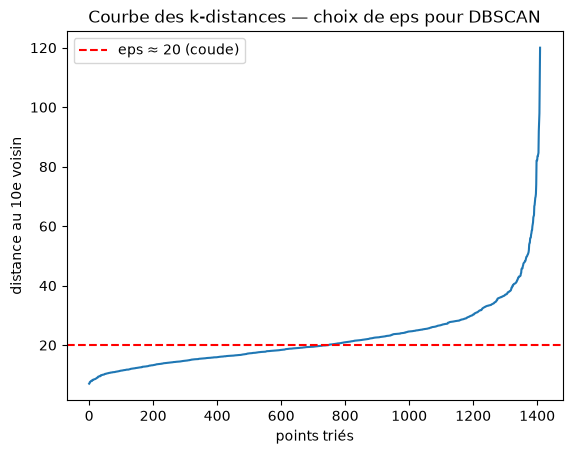

In [23]:
from sklearn.neighbors import NearestNeighbors

voisins = NearestNeighbors(n_neighbors=10).fit(X_pca)   # 10 = min_samples
dist, _ = voisins.kneighbors(X_pca)
d10 = np.sort(dist[:, -1])                                # distance au 10e voisin, triée

plt.plot(d10)
plt.axhline(20, color="red", ls="--", label="eps ≈ 20 (coude)")
plt.xlabel("points triés"); plt.ylabel("distance au 10e voisin")
plt.title("Courbe des k-distances — choix de eps pour DBSCAN"); plt.legend()

In [24]:
from sklearn.cluster import KMeans, DBSCAN
cat["cluster_kmeans"] = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X_pca)
cat["cluster_dbscan"] = DBSCAN(eps=20, min_samples=10).fit_predict(X_pca)   # eps choisi via la courbe des k-distances

nb = len(set(cat["cluster_dbscan"]) - {-1})
print("K-Means — tailles :", dict(cat["cluster_kmeans"].value_counts()))
print(f"DBSCAN  — {nb} cluster(s), {(cat['cluster_dbscan'] == -1).sum()} points en bruit")

K-Means — tailles : {1: np.int64(902), 0: np.int64(508)}
DBSCAN  — 1 cluster(s), 477 points en bruit


Comparaison des deux méthodes :
- **K-Means** forme deux groupes de tailles **508 et 902** (il *impose* k=2).
- **DBSCAN** (eps=20, choisi via la courbe des k-distances) ne dégage **qu'un seul groupe dense (~933 points) + ~477 points isolés** : sans contrainte sur le nombre de groupes, il ne « voit » pas de séparation en deux. Premier signal que la structure à 2 classes est ténue dans ces features.

### 3.4 — Évaluation par l'ARI (contre les vrais labels)

L'**ARI** compare l'affectation en clusters aux vrais labels, **uniquement sur le sous-ensemble labellisé** (seul endroit où la vérité est connue). 0 = hasard, 1 = parfait.

In [25]:
from sklearn.metrics import adjusted_rand_score
m = (cat["label"] != "inconnu").values
print("ARI K-Means :", round(adjusted_rand_score(cat.loc[m, "label"], cat.loc[m, "cluster_kmeans"]), 3))
print("ARI DBSCAN  :", round(adjusted_rand_score(cat.loc[m, "label"], cat.loc[m, "cluster_dbscan"]), 3))

ARI K-Means : 0.119
ARI DBSCAN  : 0.047


**ARI ≈ 0.12 pour K-Means, ≈ 0.05 pour DBSCAN** : dans les deux cas, l'alignement avec la pathologie est **faible**. Ce n'est pas un échec (l'énoncé l'annonçait), mais un constat convergent — les features ResNet, pré-entraînées sur ImageNet et non sur des IRM, ne séparent pas proprement « cancer » et « normal » de façon non supervisée. Visualisons pour comprendre.

### 3.5 — Visualisation 2D (clusters vs vrais labels)

Deux projections t-SNE côte à côte : à gauche les clusters K-Means, à droite les vrais labels du sous-ensemble annoté. Objectif : voir si les groupes capturent la **pathologie**… ou autre chose (l'EDA avait détecté un biais de **bordure**).

Text(0.5, 1.0, 'Vrais labels')

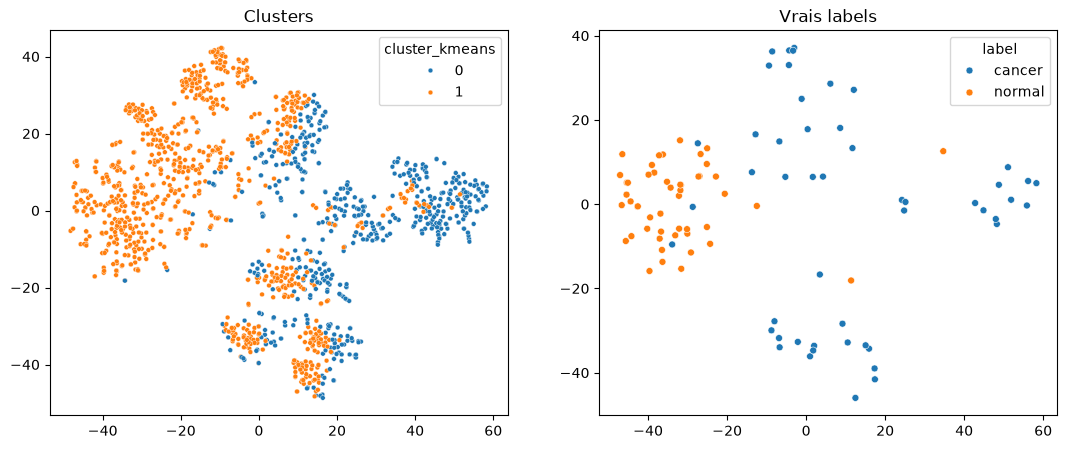

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=cat["cluster_kmeans"], s=12, ax=ax[0]).set_title("Clusters")
sns.scatterplot(x=X_2d[m,0], y=X_2d[m,1], hue=cat.loc[m,"label"], s=25, ax=ax[1]).set_title("Vrais labels")


Le graphique confirme l'ARI : le découpage en clusters **ne se superpose pas** au partage cancer/normal. La table de contingence le précise — un cluster est plutôt « cancer » (20 cancer / 2 normal), mais l'autre **mélange** 30 cancer et 47 normal. Autrement dit, **30 des 50 cancers** tombent du mauvais côté : le signal pathologique est trop subtil pour ce clustering non supervisé.

### 3.6 — Labellisation faible (pseudo-labels)

On associe chaque cluster à une classe par **vote majoritaire** des points labellisés, puis on propage ce label aux 1311 images `sans_label`.

In [27]:
corresp = cat[m].groupby("cluster_kmeans")["label"].agg(lambda s: s.value_counts().idxmax())
cat["pseudo_label"] = cat["cluster_kmeans"].map(corresp)
faible = cat[cat["label"] == "inconnu"].copy()      # le jeu faiblement labellisé


Mapping obtenu : **cluster 0 → « cancer », cluster 1 → « normal »**. Appliqué au jeu non labellisé, il produit **486 pseudo-« cancer » et 825 pseudo-« normal »** (1311 images). **Attention :** vu l'ARI faible, ces pseudo-labels sont **bruités**, à manier avec prudence — c'est exactement ce que l'étape semi-supervisée (Notebook 2) viendra corriger grâce aux vrais labels.

### 3.7 — Sauvegarde, en gardant les deux jeux séparés

On enregistre le jeu **faiblement** labellisé (pseudo-labels) et le jeu **fortement** labellisé (vrais labels) dans deux fichiers distincts — la règle d'or de l'énoncé : ne jamais les mélanger.

In [28]:
faible[["chemin","pseudo_label"]].to_csv("../outputs/faiblement_labellise.csv", index=False)
cat[cat.label!="inconnu"][["chemin","label"]].to_csv("../outputs/fortement_labellise.csv", index=False)


## Synthèse de la Partie 3

- **Réduction de dimension :** standardisation + PCA 50 comp. (46 % de variance) ; t-SNE pour la visualisation.
- **Clustering :** K-Means (k=2) et DBSCAN (eps ≈ 20, réglé via la courbe des k-distances). DBSCAN ne dégage qu'**un seul groupe + des points isolés** : aucune séparation par densité en 2 classes.
- **Évaluation :** **ARI ≈ 0.12 (K-Means)** et **≈ 0.05 (DBSCAN)** → les clusters ne capturent que faiblement la pathologie (un cluster assez pur en cancer, l'autre très mélangé).
- **Labellisation faible :** 1311 images pseudo-labellisées (486 cancer / 825 normal), **sauvegardées séparément** du jeu fort.

> **Lecture critique (point de soutenance) :** deux méthodes de clustering, le même verdict — un clustering non supervisé sur des features ImageNet ne sépare pas la pathologie. D'où tout l'intérêt de l'**approche semi-supervisée** : partir de ces pseudo-labels imparfaits, puis les **corriger** avec le petit jeu d'images expertisées — c'est l'objet du Notebook 2.

**Definition of done — Partie 3 :** features réduites · 2 algos testés et réglés · ARI calculé et interprété · clusters visualisés vs vrais labels · jeu faiblement labellisé produit et sauvegardé séparément.

*Fin du Notebook 1.*